# Function 8 - Week 3: model predictions

Compare models using leave-one-out validation and examine the latest returned output. Use the selected Gaussian process to propose one adaptive query, comparing broad and local searches with a single pure-coverage query.

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import LeaveOneOut, cross_val_predict
import sys

shared_dir = Path.cwd().resolve().parents[1] / "Shared"
if str(shared_dir) not in sys.path:
    sys.path.insert(0, str(shared_dir))
from coverage_helpers import make_coverage_space
from coverage_cache import compare_coverage_batches
from query_budget import remaining_queries, TOTAL_QUERY_WEEKS


In [2]:
# Data and output paths for this week's notebook.
# Start the kernel with this notebook's folder as its working directory.
week_dir = Path.cwd().resolve()
full_data_path = week_dir / "observations.csv"

if not (week_dir / "model_predictions.ipynb").is_file() or not full_data_path.is_file():
    raise FileNotFoundError(
        "Run this notebook with its own folder as the working directory; "
        "model_predictions.ipynb and observations.csv must be together."
    )

figures = week_dir / "figures"
figures.mkdir(parents=True, exist_ok=True)

In [3]:
# Basic data load
print(f"Loading data from: {full_data_path}")
data = pd.read_csv(full_data_path)

Loading data from: C:\_Source\Imperial-ML-AI-Live\Capstone\imperial-capstone\stage-2-bbo\notebooks\Function_8\Week_03\observations.csv


In [4]:
# Column inspection
columns = data.columns
print("Columns: ", columns)

Columns:  Index(['observation_id', 'source_round', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6',
       'x7', 'x8', 'y'],
      dtype='str')


In [5]:
# Where we pray for good data, aka checking for nulls
print (data.isna().sum())

observation_id    0
source_round      0
x1                0
x2                0
x3                0
x4                0
x5                0
x6                0
x7                0
x8                0
y                 0
dtype: int64


In [6]:
# Splitting our data into inputs X and outputs y
output_column = "y"
# The course names inputs x1, x2, ...; preserve their CSV column order.
input_columns = [
    name for name in data.columns
    if name.startswith("x") and name[1:].isdigit()
]

#print("Input columns: ", input_columns)
#print("Output column: ", output_column)

X = data[input_columns]
y = data[output_column]

#print("The inputs are given by :")
#print(X.head())
#print("The outputs are given by :")
#print(y[:5])


In [7]:
# Set up leave-one-out validation for the model comparisons that follow.
cross_validation = LeaveOneOut()
number_of_folds = cross_validation.get_n_splits(X)

print(f"Validation folds: {number_of_folds}")
print(f"Training observations per fold: {len(X) - 1}")
print("Validation observations per fold: 1")

Validation folds: 42
Training observations per fold: 41
Validation observations per fold: 1


In [8]:
# Identify the one new observation in this week's accumulated data.
latest_round = int(data["source_round"].max())
latest_indices = data.index[data["source_round"].eq(latest_round)]
if latest_round == 0 or len(latest_indices) != 1:
    raise ValueError("This weekly comparison expects one latest returned observation.")
latest_index = latest_indices[0]
latest_position = X.index.get_loc(latest_index)
latest_output = float(y.loc[latest_index])
other_observations = data["source_round"].lt(latest_round).to_numpy()

print(f"Latest observation: {data.loc[latest_index, 'observation_id']}")
print(f"Latest output: {latest_output:.6f}")
print(f"Previous best: {y.loc[data['source_round'].lt(latest_round)].max():.6f}")
print("Maximise the original output: higher is better.")
previous_best = float(y.loc[other_observations].max())
latest_rank = int(y.rank(method="min", ascending=False).loc[latest_index])
print(f"Latest output rank: {latest_rank}/{len(y)} (1 = highest output).")
print(f"Change from the previous best: {latest_output - previous_best:.6f}.")
if latest_output > previous_best:
    print("The latest output improves the previous best.")
else:
    print("The latest output does not improve the previous best.")
data.loc[[y.idxmax(), latest_index], ["observation_id", *input_columns, output_column]]

Latest observation: round-02
Latest output: 9.518300
Previous best: 9.598482
Maximise the original output: higher is better.
Latest output rank: 2/42 (1 = highest output).
Change from the previous best: -0.080182.
The latest output does not improve the previous best.


,observation_id,x1,x2,x3,x4,x5,x6,x7,x8,y
14,initial-015,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482
41,round-02,0.000000,0.000000,0.000000,0.000000,0.999999,0.000000,0.000000,0.999999,9.518300


In [9]:
# Establish a mean-prediction benchmark using leave-one-out validation.
baseline_model = DummyRegressor(strategy="mean")

baseline_predictions = cross_val_predict(
    baseline_model,
    X,
    y,
    cv=cross_validation,
)

baseline_rmse = root_mean_squared_error(y, baseline_predictions)

print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline RMSE: 1.0161


In [10]:
# Evaluate whether linear input effects improve on the mean baseline.
linear_model = LinearRegression()

linear_predictions = cross_val_predict(
    linear_model,
    X,
    y,
    cv=cross_validation,
)

linear_rmse = root_mean_squared_error(y, linear_predictions)
linear_improvement = 1 - linear_rmse / baseline_rmse

print(f"Mean baseline RMSE: {baseline_rmse:.4f}")
print(f"Linear regression RMSE: {linear_rmse:.4f}")
print(f"RMSE reduction against baseline: {linear_improvement:.1%}")

Mean baseline RMSE: 1.0161
Linear regression RMSE: 0.4880
RMSE reduction against baseline: 52.0%


In [11]:
# Evaluate linear regression with a penalty on large coefficients.
ridge_model = Ridge(alpha=1.0)

ridge_predictions = cross_val_predict(
    ridge_model,
    X,
    y,
    cv=cross_validation,
)

ridge_rmse = root_mean_squared_error(y, ridge_predictions)
ridge_improvement = 1 - ridge_rmse / baseline_rmse

print(f"Ridge regression RMSE: {ridge_rmse:.4f}")
print(f"RMSE reduction against baseline: {ridge_improvement:.1%}")

Ridge regression RMSE: 0.4838
RMSE reduction against baseline: 52.4%


In [12]:
# Evaluate a model that can capture curved input-output relationships.
kernel_ridge_model = KernelRidge(
    alpha=0.1,
    kernel="rbf",
    gamma=1.0,
)

kernel_ridge_predictions = cross_val_predict(
    kernel_ridge_model,
    X,
    y,
    cv=cross_validation,
)

kernel_ridge_rmse = root_mean_squared_error(y, kernel_ridge_predictions)
kernel_ridge_improvement = 1 - kernel_ridge_rmse / baseline_rmse

print(f"Kernel ridge regression RMSE: {kernel_ridge_rmse:.4f}")
print(f"RMSE reduction against baseline: {kernel_ridge_improvement:.1%}")

Kernel ridge regression RMSE: 1.4291
RMSE reduction against baseline: -40.6%


In [13]:
# Evaluate a Gaussian process on the original output scale, as in Function 4.
# Normalisation and kernel fitting happen inside each training fold.
# Assume noise SD is 10% of training output SD; the true noise level is unknown.
noise_fraction = 0.10

gaussian_process_model = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (0.01, 100.0)) * RBF(
        length_scale=0.3,
        length_scale_bounds=(0.03, 2.0),
    ),
    alpha=noise_fraction ** 2,
    normalize_y=True,
    n_restarts_optimizer=3,
    random_state=42,
)
gaussian_process_predictions = cross_val_predict(
    gaussian_process_model, X, y, cv=cross_validation,
)
gaussian_process_rmse = root_mean_squared_error(y, gaussian_process_predictions)
print(f"Gaussian-process RMSE: {gaussian_process_rmse:.4f}")
print(f"RMSE reduction against baseline: {1 - gaussian_process_rmse / baseline_rmse:.1%}")

Gaussian-process RMSE: 0.2874
RMSE reduction against baseline: 71.7%


In [14]:
# Compare every model in the same original output units, retaining all observations.
models = {
    "Mean baseline": baseline_model,
    "Linear regression": linear_model,
    "Ridge": ridge_model,
    "Kernel ridge": kernel_ridge_model,
    "Gaussian process": gaussian_process_model,
}
held_out_predictions = {
    "Mean baseline": baseline_predictions,
    "Linear regression": linear_predictions,
    "Ridge": ridge_predictions,
    "Kernel ridge": kernel_ridge_predictions,
    "Gaussian process": gaussian_process_predictions,
}
comparison_rows = []
for name, predictions in held_out_predictions.items():
    error = root_mean_squared_error(y, predictions)
    comparison_rows.append({
        "Model": name,
        "LOO RMSE": error,
        "LOO MAE": mean_absolute_error(y, predictions),
        "RMSE reduction (%)": 100 * (1 - error / baseline_rmse),
    })
model_comparison = pd.DataFrame(comparison_rows).sort_values("LOO RMSE").reset_index(drop=True)
print("RMSE gives large errors more weight; MAE reports average absolute error.")
print(f"All models use the same {len(y)} leave-one-out folds and all observations are retained.")
model_comparison.round(4)

RMSE gives large errors more weight; MAE reports average absolute error.
All models use the same 42 leave-one-out folds and all observations are retained.


,Model,LOO RMSE,LOO MAE,RMSE reduction (%)
0,Gaussian process,0.2874,0.2260,71.7128
1,Ridge,0.4838,0.3975,52.3893
2,Linear regression,0.4880,0.3943,51.9701
3,Mean baseline,1.0161,0.8458,0.0000
4,Kernel ridge,1.4291,0.9893,-40.6407


In [15]:
# Inspect the latest-result fold: train on earlier observations and predict the new one.
# Model settings were chosen for this analysis, so this is a retrospective check.
# The other-row metric below uses folds that include the latest observation in training.
latest_rows = []
for name, predictions in held_out_predictions.items():
    residuals = predictions - y.to_numpy()
    latest_prediction = float(predictions[latest_position])
    latest_error = latest_prediction - latest_output
    latest_rows.append({
        "Model": name,
        "Latest held-out prediction": latest_prediction,
        "Latest error": latest_error,
        "Latest absolute error (%)": 100 * abs(latest_error) / abs(latest_output),
        "Latest share of squared error (%)": 100 * latest_error ** 2 / np.sum(residuals ** 2),
        "Other rows LOO RMSE": root_mean_squared_error(
            y.to_numpy()[other_observations], predictions[other_observations],
        ),
    })
latest_prediction_review = pd.DataFrame(latest_rows).sort_values("Latest absolute error (%)").reset_index(drop=True)
print(f"Actual latest output: {latest_output:.6f}")
print(f"Each prediction of this latest output used only the {other_observations.sum()} earlier observations.")
print("Other rows LOO RMSE excludes this row from scoring, not from their training folds.")
latest_prediction_review.round(4)

Actual latest output: 9.518300
Each prediction of this latest output used only the 41 earlier observations.
Other rows LOO RMSE excludes this row from scoring, not from their training folds.


,Model,Latest held-out prediction,Latest error,Latest absolute error (%),Latest share of squared error (%),Other rows LOO RMSE
0,Gaussian process,9.8087,0.2904,3.0511,2.4306,0.2874
1,Ridge,10.0686,0.5503,5.7812,3.0804,0.4820
2,Linear regression,10.6590,1.1407,11.9847,13.0079,0.4607
3,Mean baseline,7.8563,-1.6620,17.4609,6.3695,0.9951
4,Kernel ridge,5.1821,-4.3362,45.5561,21.9204,1.2781


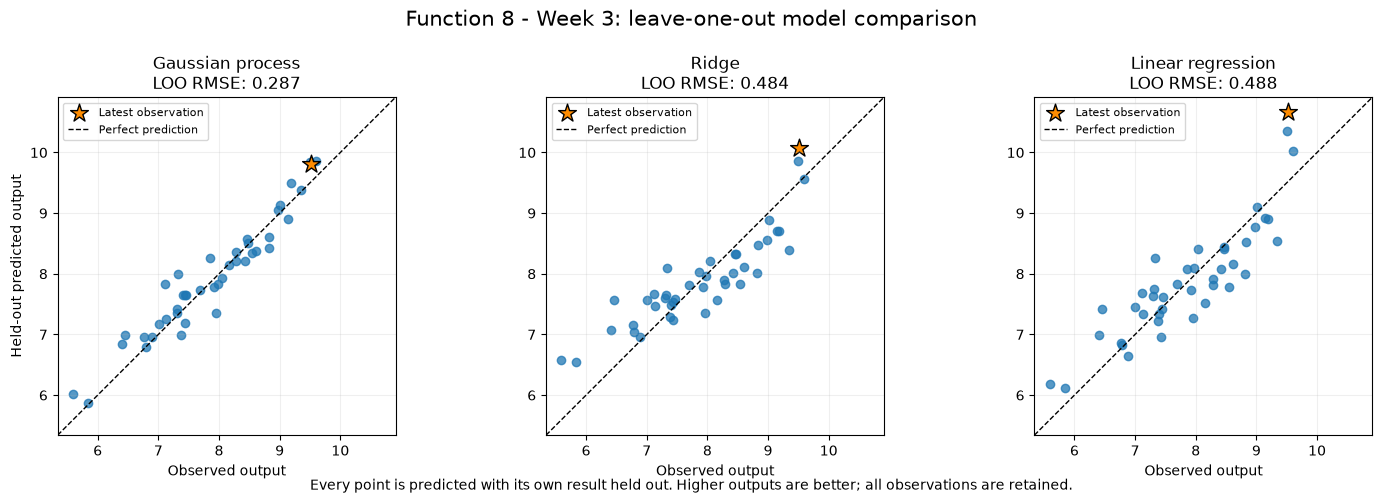

In [16]:
# Plot the three lowest-RMSE methods on the same output scale.
# The comparison table retains every model, including the mean baseline.
plot_models = model_comparison.loc[
    model_comparison["Model"].ne("Mean baseline"), "Model"
].head(3).tolist()
plot_values = np.concatenate([
    y.to_numpy(), *(held_out_predictions[name] for name in plot_models),
])
plot_padding = 0.05 * np.ptp(plot_values)
plot_limits = (
    float(plot_values.min() - plot_padding),
    float(plot_values.max() + plot_padding),
)

fig, axes = plt.subplots(1, len(plot_models), figsize=(15, 5))
for ax, name in zip(axes, plot_models):
    predictions = held_out_predictions[name]
    ax.scatter(y.to_numpy()[other_observations], predictions[other_observations], alpha=0.75)
    ax.scatter(
        latest_output, predictions[latest_position], marker="*", s=180,
        color="darkorange", edgecolor="black", label="Latest observation",
    )
    ax.plot(plot_limits, plot_limits, "k--", linewidth=1, label="Perfect prediction")
    ax.set(
        xlim=plot_limits, ylim=plot_limits, xlabel="Observed output",
        title=f"{name}\nLOO RMSE: {root_mean_squared_error(y, predictions):.3f}",
    )
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("Held-out predicted output")
fig.suptitle("Function 8 - Week 3: leave-one-out model comparison", fontsize=15)
fig.text(
    0.5, 0.02,
    "Every point is predicted with its own result held out. Higher outputs are better; all observations are retained.",
    ha="center", fontsize=10,
)
fig.tight_layout(rect=(0, 0.055, 1, 0.95))
fig.savefig(figures / "model-comparison-validation.png", dpi=160, bbox_inches="tight")
plt.show()

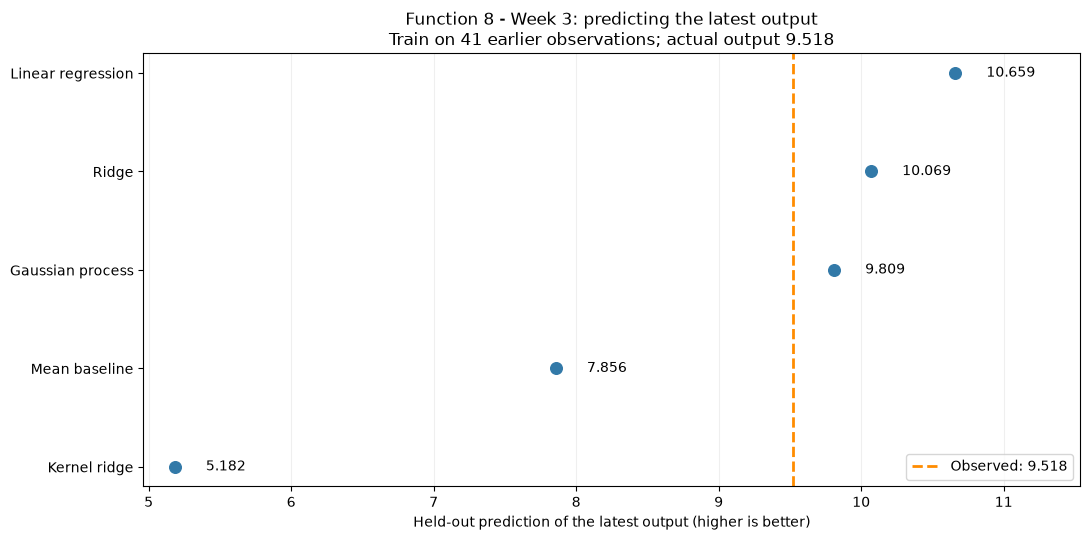

In [17]:
# Compare each model's held-out prediction with the latest result.
latest_chart = latest_prediction_review.sort_values("Latest held-out prediction", ascending=False)
fig, ax = plt.subplots(figsize=(11, 5.5))
positions = np.arange(len(latest_chart))
values = latest_chart["Latest held-out prediction"].to_numpy()
ax.scatter(values, positions, color="#3279a8", s=70, zorder=3)
ax.set_yticks(positions, latest_chart["Model"])
ax.invert_yaxis()
ax.axvline(
    latest_output, color="darkorange", linewidth=2, linestyle="--",
    label=f"Observed: {latest_output:.3f}",
)
chart_min = min(latest_output, values.min())
chart_max = max(latest_output, values.max())
chart_padding = 0.04 * (chart_max - chart_min)
for position, value in zip(positions, values):
    ax.text(value + chart_padding, position, f"{value:.3f}", va="center", fontsize=10)
ax.set_xlim(chart_min - chart_padding, chart_max + 4 * chart_padding)
ax.set_xlabel("Held-out prediction of the latest output (higher is better)")
ax.set_title(
    f"Function 8 - Week 3: predicting the latest output\n"
    f"Train on {other_observations.sum()} earlier observations; actual output {latest_output:.3f}"
)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(figures / "latest-output-predictions.png", dpi=160, bbox_inches="tight")
plt.show()

In [18]:
# Check fitting with the new result included, separately from held-out performance.
# These fitted values are training predictions and are not validation evidence.
fitted_models = {}
fit_review_rows = []
for name, model in models.items():
    fitted_model = clone(model).fit(X, y)
    fitted_models[name] = fitted_model
    fitted_latest = float(fitted_model.predict(X.loc[[latest_index]])[0])
    fit_review_rows.append({
        "Model": name,
        "Observed latest output": latest_output,
        "Held-out prediction": held_out_predictions[name][latest_position],
        "Fitted prediction (training)": fitted_latest,
    })
print("Including the new output may let a model fit it closely; this does not mean it predicted it in advance.")
pd.DataFrame(fit_review_rows).round(4)

Including the new output may let a model fit it closely; this does not mean it predicted it in advance.


,Model,Observed latest output,Held-out prediction,Fitted prediction (training)
0,Mean baseline,9.5183,7.8563,7.8959
1,Linear regression,9.5183,10.6590,10.1955
2,Ridge,9.5183,10.0686,9.8851
3,Kernel ridge,9.5183,5.1821,9.0128
4,Gaussian process,9.5183,9.8087,9.5250


In [19]:
# Summarise the evidence before moving on to query selection.
lowest_rmse = model_comparison.iloc[0]
lowest_mae = model_comparison.loc[model_comparison["LOO MAE"].idxmin()]
closest_latest = latest_prediction_review.iloc[0]
lowest_rmse_latest = latest_prediction_review.loc[
    latest_prediction_review["Model"].eq(lowest_rmse["Model"])
].iloc[0]

print(f"Lowest overall LOO RMSE: {lowest_rmse['Model']} ({lowest_rmse['LOO RMSE']:.4f}).")
print(f"RMSE reduction against mean baseline: {lowest_rmse['RMSE reduction (%)']:.1f}%.")
print(f"Lowest overall LOO MAE: {lowest_mae['Model']} ({lowest_mae['LOO MAE']:.4f}).")
print(
    f"Closest prediction of the latest held-out result: {closest_latest['Model']}, "
    f"{closest_latest['Latest held-out prediction']:.4f} versus actual {latest_output:.4f}."
)
print(f"Its absolute error on that result: {closest_latest['Latest absolute error (%)']:.1f}%.")
print(
    f"The latest result contributes {lowest_rmse_latest['Latest share of squared error (%)']:.1f}% "
    "of the lowest-RMSE model's total held-out squared error."
)
print("Overall prediction error and ability to locate a better maximum are different assessments.")
print("This comparison does not establish the location or value of the global maximum.")
print("Model comparison is complete; query selection follows below.")

Lowest overall LOO RMSE: Gaussian process (0.2874).
RMSE reduction against mean baseline: 71.7%.
Lowest overall LOO MAE: Gaussian process (0.2260).
Closest prediction of the latest held-out result: Gaussian process, 9.8087 versus actual 9.5183.
Its absolute error on that result: 3.1%.
The latest result contributes 2.4% of the lowest-RMSE model's total held-out squared error.
Overall prediction error and ability to locate a better maximum are different assessments.
This comparison does not establish the location or value of the global maximum.
Model comparison is complete; query selection follows below.


In [20]:
# Retain the Week 2 Gaussian-process choice; review the updated validation above.
selected_model = fitted_models["Gaussian process"]

print(f"Selected model: {type(selected_model).__name__}")
print(f"Observations used for the final fit: {len(X)}")
print(f"Fitted kernel: {selected_model.kernel_}")
print(f"Assumed noise SD: {noise_fraction * y.std(ddof=0):.4f} output units")
print("Use one model-guided query, then reassess after its output returns.")
print("Keep both promising regions and the full input space in the candidate search.")

Selected model: GaussianProcessRegressor
Observations used for the final fit: 42
Fitted kernel: 1.76**2 * RBF(length_scale=1.39)
Assumed noise SD: 0.0992 output units
Use one model-guided query, then reassess after its output returns.
Keep both promising regions and the full input space in the candidate search.


In [21]:
# Search the full input space and a denser local box around the best observation.
# Every coordinate remains free to vary. The local radius is a search setting, not a fitted parameter.
candidate_inputs = pd.DataFrame(
    make_coverage_space(X.shape[1], power=14, seed=42),
    columns=input_columns,
)
unit_candidates = candidate_inputs.to_numpy() / 0.999999
local_radius = 0.15
best_inputs = X.loc[y.idxmax()].to_numpy()
local_lower = np.maximum(0.0, best_inputs - local_radius)
local_upper = np.minimum(0.999999, best_inputs + local_radius)
local_best_inputs = pd.DataFrame(
    local_lower + unit_candidates * (local_upper - local_lower),
    columns=input_columns,
)

candidate_sources = [
    candidate_inputs.assign(candidate_source="Full input space"),
    local_best_inputs.assign(candidate_source="Near best observation"),
]

# The returned corner and the existing best occupy different regions; search both.
latest_inputs = X.loc[latest_index].to_numpy()
latest_lower = np.maximum(0.0, latest_inputs - local_radius)
latest_upper = np.minimum(0.999999, latest_inputs + local_radius)
local_latest_inputs = pd.DataFrame(
    latest_lower + unit_candidates * (latest_upper - latest_lower),
    columns=input_columns,
)
candidate_sources.append(
    local_latest_inputs.assign(candidate_source="Near latest corner")
)

# Compare with an independently optimised single-query coverage alternative.
single_coverage_comparison = compare_coverage_batches(
    existing=X,
    cache_dir=week_dir / ".coverage-cache",
    max_queries=1,
)
single_coverage_inputs = pd.DataFrame(
    single_coverage_comparison["proposed_batches"][1],
    columns=input_columns,
)
candidate_sources.append(
    single_coverage_inputs.assign(candidate_source="Single coverage query")
)
candidate_inputs = pd.concat(
    candidate_sources, ignore_index=True,
).drop_duplicates(subset=input_columns).reset_index(drop=True)

coverage_before = single_coverage_comparison["results"][0]["max_distance"]
coverage_after = single_coverage_comparison["results"][1]["max_distance"]
print(f"Candidate locations before excluding observed inputs: {len(candidate_inputs):,}")
print(f"Local search radius: {local_radius} per coordinate, clipped to the allowed input range.")
print(f"The single pure-coverage query reduces the assessed worst gap by {1 - coverage_after / coverage_before:.1%}.")
print("That geometric reduction does not measure improvement in the observed output.")

q=0: computed and saved


q=1: computed and saved


Candidate locations before excluding observed inputs: 49,920
Local search radius: 0.15 per coordinate, clipped to the allowed input range.
The single pure-coverage query reduces the assessed worst gap by 0.2%.
That geometric reduction does not measure improvement in the observed output.


In [22]:
# Rank candidates by the same UCB rule used for Function 4.
# UCB = posterior mean + exploration weight * posterior standard deviation.
# Posterior SD measures uncertainty in the fitted function, excluding new observation noise.
# The acquisition score is not a predicted output or a calibrated confidence guarantee.
exploration_weight = 1.96
observed_coordinates = set(map(tuple, X.round(6).to_numpy()))
is_new_candidate = [
    tuple(row) not in observed_coordinates
    for row in candidate_inputs[input_columns].round(6).to_numpy()
]
bayesian_candidates = candidate_inputs.loc[is_new_candidate].copy().reset_index(drop=True)

candidate_mean, candidate_uncertainty = selected_model.predict(
    bayesian_candidates[input_columns], return_std=True,
)
bayesian_candidates["posterior_mean"] = candidate_mean
bayesian_candidates["posterior_std"] = candidate_uncertainty
bayesian_candidates["ucb"] = candidate_mean + exploration_weight * candidate_uncertainty
bayesian_candidates = bayesian_candidates.sort_values("ucb", ascending=False).reset_index(drop=True)
recommended_candidate = bayesian_candidates.iloc[0]

# Show the strongest candidate from each route, including pure coverage.
candidate_comparison = bayesian_candidates.loc[
    bayesian_candidates.groupby("candidate_source")["ucb"].idxmax()
].sort_values("ucb", ascending=False)
print(f"Unobserved candidate locations: {len(bayesian_candidates):,}")
print(f"Best observed output: {y.max():.6f}")
print(f"Exploration weight: {exploration_weight}")
print("Best individual alternative from each candidate source:")
candidate_comparison.round(6)

Unobserved candidate locations: 49,918
Best observed output: 9.598482
Exploration weight: 1.96
Best individual alternative from each candidate source:


,x1,x2,x3,x4,x5,x6,x7,x8,candidate_source,posterior_mean,posterior_std,ucb
0,0.000000,0.000000,0.00000,0.999999,0.999999,0.999999,0.000000,0.000000,Full input space,9.504754,0.782429,11.038314
149,0.000000,0.215956,0.00000,0.188786,0.553935,0.651055,0.338307,0.743085,Near best observation,9.996039,0.182695,10.354122
372,0.150000,0.150000,0.00000,0.150000,0.849999,0.150000,0.150000,0.849999,Near latest corner,9.905747,0.157204,10.213866
7955,0.139599,0.140131,0.14216,0.679746,0.654662,0.690608,0.522666,0.947401,Single coverage query,9.451917,0.289761,10.019848


In [23]:
# Summarise one proposed query and check sensitivity to the exploration weight.
# The maximum is over our sampled candidates, not a proven global maximum.
next_query = recommended_candidate[input_columns].astype(float).round(6)
next_query_inputs = pd.DataFrame([next_query.to_numpy()], columns=input_columns)
next_mean, next_std = selected_model.predict(next_query_inputs, return_std=True)

if not np.isfinite(next_query.to_numpy()).all() or not next_query.between(0, 0.999999).all():
    raise ValueError("The proposed query is outside the allowed input space.")
if tuple(next_query) in observed_coordinates:
    raise ValueError("The proposed query has already been observed.")

print("Proposed next query (input-column order):")
print(", ".join(f"{name}={value:.6f}" for name, value in next_query.items()))
print("Portal input: " + "-".join(f"{value:.6f}" for value in next_query))
print(f"Candidate source: {recommended_candidate['candidate_source']}")
print("Reason: highest sampled UCB score across the broad, local and single-coverage alternatives.")
print(f"Best observed output: {y.max():.6f}")
print(f"Predicted output at the proposed query: {next_mean[0]:.6f}")
print(f"Posterior standard deviation: {next_std[0]:.6f}")
print(f"Predicted improvement from the mean: {next_mean[0] - y.max():.6f}")
print(f"UCB acquisition score: {next_mean[0] + exploration_weight * next_std[0]:.6f}")
if next_mean[0] <= y.max():
    print("This query is model-guided exploration: its predicted mean is below the current best.")
    print("It earns its place through uncertainty about a potentially better region, rather than predicted mean improvement.")
else:
    print("This query combines predicted mean improvement with exploration of model uncertainty.")
print("Decision: use this one adaptive model-guided query, then review the returned output before planning another.")
print("The prediction remains conditional on the fitted kernel, noise assumption and sampled candidate space.")
print("This is a model-based proposal, not a guaranteed improvement or a submission.")

# Check noise assumptions at this same proposed location; do not refit selected_model.
# This is a sensitivity check, not a search for the best noise setting.
noise_sensitivity = []
for assumed_noise_fraction in [0.03, noise_fraction, 0.30]:
    if assumed_noise_fraction == noise_fraction:
        sensitivity_model = selected_model
    else:
        sensitivity_model = clone(selected_model).set_params(alpha=assumed_noise_fraction ** 2)
        sensitivity_model.fit(X, y)
    sensitivity_mean, sensitivity_std = sensitivity_model.predict(next_query_inputs, return_std=True)
    noise_sensitivity.append({
        "Assumed noise fraction": assumed_noise_fraction,
        "Predicted output": sensitivity_mean[0],
        "Posterior SD": sensitivity_std[0],
        "Predicted mean improvement": sensitivity_mean[0] - y.max(),
    })

print("Predictions at the proposed query under different noise assumptions:")
print(pd.DataFrame(noise_sensitivity).round(6).to_string(index=False))
print("The noise fraction is an assumption; these checks do not establish the true noise level.")

exploration_sensitivity = []
for weight in [0.0, 1.0, 1.96, 3.0]:
    scores = bayesian_candidates["posterior_mean"] + weight * bayesian_candidates["posterior_std"]
    candidate = bayesian_candidates.loc[scores.idxmax()]
    exploration_sensitivity.append({
        "Exploration weight": weight,
        **candidate[input_columns].to_dict(),
        "Predicted output": candidate["posterior_mean"],
        "Posterior SD": candidate["posterior_std"],
    })

pure_exploitation = exploration_sensitivity[0]
pure_mean_gain = pure_exploitation["Predicted output"] - y.max()
print(f"The best sampled mean predicts {pure_exploitation['Predicted output']:.6f}: gain {pure_mean_gain:.6f} over the best observed output.")
if abs(pure_mean_gain) < pure_exploitation["Posterior SD"]:
    print("That mean difference is smaller than its posterior SD; pure exploitation offers no clear predicted gain.")
print("Selected locations under different exploration weights (0 means pure exploitation):")
pd.DataFrame(exploration_sensitivity).round(6)

Proposed next query (input-column order):
x1=0.000000, x2=0.000000, x3=0.000000, x4=0.999999, x5=0.999999, x6=0.999999, x7=0.000000, x8=0.000000
Portal input: 0.000000-0.000000-0.000000-0.999999-0.999999-0.999999-0.000000-0.000000
Candidate source: Full input space
Reason: highest sampled UCB score across the broad, local and single-coverage alternatives.
Best observed output: 9.598482
Predicted output at the proposed query: 9.504754
Posterior standard deviation: 0.782429
Predicted improvement from the mean: -0.093728
UCB acquisition score: 11.038314
This query is model-guided exploration: its predicted mean is below the current best.
It earns its place through uncertainty about a potentially better region, rather than predicted mean improvement.
Decision: use this one adaptive model-guided query, then review the returned output before planning another.
The prediction remains conditional on the fitted kernel, noise assumption and sampled candidate space.
This is a model-based proposal,

Predictions at the proposed query under different noise assumptions:
 Assumed noise fraction  Predicted output  Posterior SD  Predicted mean improvement
                   0.03          9.231199      0.819787                   -0.367283
                   0.10          9.504754      0.782429                   -0.093728
                   0.30          9.958698      0.747356                    0.360216
The noise fraction is an assumption; these checks do not establish the true noise level.
The best sampled mean predicts 10.084674: gain 0.486192 over the best observed output.
Selected locations under different exploration weights (0 means pure exploitation):


,Exploration weight,x1,x2,x3,x4,x5,x6,x7,x8,Predicted output,Posterior SD
0,0.00,0.109907,0.266577,0.098285,0.151883,0.930579,0.504796,0.170477,0.563507,10.084674,0.221228
1,1.00,0.006540,0.630171,0.029982,0.344880,0.976847,0.572387,0.059559,0.484115,10.014850,0.327259
2,1.96,0.000000,0.000000,0.000000,0.999999,0.999999,0.999999,0.000000,0.000000,9.504754,0.782429
3,3.00,0.000000,0.000000,0.000000,0.999999,0.999999,0.999999,0.000000,0.000000,9.504754,0.782429


## Evidence for model-led queries

Use **GP RMSE / mean-baseline RMSE** as the main comparison: below 1 means better
held-out predictions than the baseline; 0.2 means one fifth of its error. The
existing model table reports the equivalent percentage reduction. This measures
predictive usefulness on the observed data, not the fraction of the input space explored.

Also check how many different locations the tested exploration weights select.
One location means this choice is stable across those weights for this candidate
sample and fitted model. Several locations mean the exploration trade-off still
changes the decision. Retain the noise-sensitivity check above.

The query budget provides context, not a confidence score. These checks do not
establish that exploration is complete or that the global optimum has been found;
GP uncertainty depends on its [kernel and noise assumptions](https://scikit-learn.org/stable/modules/gaussian_process.html).


In [24]:
# Reuse the validation and sensitivity results already calculated above: no new fits.
relative_gp_error = gaussian_process_rmse / baseline_rmse if baseline_rmse > 0 else None
weight_choices = pd.DataFrame(exploration_sensitivity)
distinct_choices = len(weight_choices[input_columns].round(6).drop_duplicates())

model_evidence = pd.DataFrame([
    {
        "Check": "GP / mean-baseline held-out RMSE",
        "Result": f"{relative_gp_error:.3f} (1.000 = baseline)" if relative_gp_error is not None else "Undefined: baseline error is zero",
    },
    {
        "Check": "RMSE in output units: GP / baseline",
        "Result": f"{gaussian_process_rmse:.4f} / {baseline_rmse:.4f}",
    },
    {
        "Check": "Distinct proposed locations across exploration weights",
        "Result": f"{distinct_choices} across {len(weight_choices)} tested weights (six-decimal inputs)",
    },
    {
        "Check": "Queries available from the start of this week",
        "Result": f"{remaining_queries(week_dir)} of the {TOTAL_QUERY_WEEKS}-query course allowance",
    },
])
model_evidence


,Check,Result
0,GP / mean-baseline held-out RMSE,0.283 (1.000 = baseline)
1,RMSE in output units: GP / baseline,0.2874 / 1.0161
2,Distinct proposed locations across exploration...,3 across 4 tested weights (six-decimal inputs)
3,Queries available from the start of this week,11 of the 13-query course allowance


## Decision

Retain the Gaussian process: its held-out RMSE is **0.2874**, compared with **0.4838** for ridge, **0.4880** for linear regression and **1.0161** for the mean baseline. It also has the lowest MAE; the linear models help, but this comparison supports the GP.

Use one query at the existing exploration weight of **1.96**. Its predicted mean (**9.504754**) is below the current best (**9.598482**), so uncertainty motivates the choice. The four tested weights select three locations, and the tested noise assumptions give means from **9.231199 to 9.958698** at this query. Reassess after the result returns.
